<a href="https://colab.research.google.com/github/Pandey002/ddpm-mnist-from-scratch/blob/main/Diffusion_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1)
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
images, labels = next(iter(dataloader))
print(images.shape)
print(images.min(), images.max())

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.76MB/s]


torch.Size([64, 1, 28, 28])
tensor(-1.) tensor(1.)


In [3]:
print(images.min(), images.max())

tensor(-1.) tensor(1.)


In [4]:
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)

In [5]:
print(betas.shape)
print(betas[:5])
print(betas[-5:])

torch.Size([1000])
tensor([1.0000e-04, 1.1992e-04, 1.3984e-04, 1.5976e-04, 1.7968e-04])
tensor([0.0199, 0.0199, 0.0200, 0.0200, 0.0200])


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)
alphas = alphas.to(device)

In [8]:
print(alphas[:5])
print(alpha_bar[:5])
print(alpha_bar[-1])

tensor([0.9999, 0.9999, 0.9999, 0.9998, 0.9998])
tensor([0.9999, 0.9998, 0.9996, 0.9995, 0.9993])
tensor(4.0358e-05)


In [9]:
def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)
    sqrt_alpha_bar = torch.sqrt(alpha_bar[t])[:, None, None, None]
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar[t])[:, None, None, None]
    xt = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise
    return xt, noise

In [10]:
t = torch.tensor([0])
xt,noise = forward_diffusion(images[:1],t)
print(xt.shape)

torch.Size([1, 1, 28, 28])


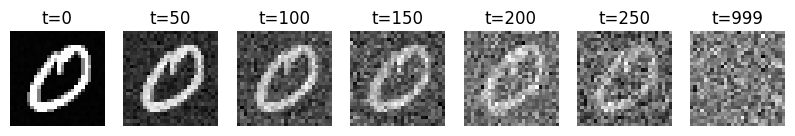

In [11]:
import matplotlib.pyplot as plt

x0 = images[:1]
steps = [0, 50, 100, 150, 200, 250, 999]
plt.figure(figsize=(10,2))

for i, step in enumerate(steps):
    t = torch.tensor([step])
    xt, _ = forward_diffusion(x0, t)
    plt.subplot(1, len(steps), i+1)
    plt.imshow(xt[0].permute(1,2,0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"t={step}")
plt.show()

In [12]:
def dummy_model(x, t):
    return torch.randn_like(x)

In [13]:
import torch.nn.functional as F
x0 = images[:1]
t = torch.randint(0, T, (1,))
xt, actual_noise = forward_diffusion(x0, t)
predicted_noise = dummy_model(xt, t)
loss = F.mse_loss(predicted_noise, actual_noise)
print(loss)

tensor(2.0732)


In [16]:
import torch.nn as nn
import math

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim
        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim*4),
            nn.SiLU(),
            nn.Linear(emb_dim*4, emb_dim)
        )
    def forward(self, t):
        half = self.emb_dim // 2
        freqs = torch.exp(
            -math.log(10000)*torch.arange(half, device=t.device)/(half - 1)
        )
        args = t[:, None].float()*freqs[None]
        emb  = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.proj(emb)

In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.time_proj = nn.Linear(emb_dim, out_ch)
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, temb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_proj(self.act(temb))[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.res_conv(x)

In [18]:
class UNet(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(emb_dim)

        #ENCODER
        self.enc1 = ConvBlock(1,   64,  emb_dim)
        self.enc2 = ConvBlock(64,  128, emb_dim)
        self.pool = nn.MaxPool2d(2)

        # BOTTLENECK
        self.bot  = ConvBlock(128, 128, emb_dim)

        # DECODER
        self.up1  = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.dec1 = ConvBlock(128, 64, emb_dim)

        # OUTPUT
        self.out  = nn.Conv2d(64, 1, 1)

    def forward(self, x, t):
        temb = self.time_emb(t)

        # ENCODER
        e1 = self.enc1(x, temb)
        e2 = self.enc2(self.pool(e1), temb)

        # BOTTLENECK
        b  = self.bot(e2, temb)

        # DECODER + SKIP
        d1 = self.up1(b)
        d1 = self.dec1(torch.cat([d1, e1], dim=1), temb)

        return self.out(d1)



In [22]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alpha_bar = alpha_bar.to(device)
alphas    = alphas.to(device)

model     = UNet(emb_dim=128).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)

epochs = 1    #can be increased according to your computation availability

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x0, _ in dataloader:
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        xt, noise = forward_diffusion(x0, t)
        pred = model(xt, t)
        loss = F.mse_loss(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    avg = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs}  loss: {avg:.4f}")

Epoch 1/1  loss: 0.0454


In [23]:
@torch.no_grad()
def reverse_step(model, xt, t_val, alphas, alpha_bar):
    t = torch.tensor([t_val], device=xt.device)
    alpha_t = alphas[t_val]
    alpha_bar_t = alpha_bar[t_val]
    pred_noise = model(xt, t)
    mean = (1 / torch.sqrt(alpha_t)) * (
        xt-((1-alpha_t)/torch.sqrt(1-alpha_bar_t))*pred_noise
    )
    if t_val > 0:
        beta  = 1-alpha_t
        sigma = torch.sqrt(beta)
        return mean + sigma * torch.randn_like(xt)
    return mean

@torch.no_grad()
def sample(model, n=16):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    for t_val in reversed(range(T)):
        x = reverse_step(model, x, t_val, alphas, alpha_bar)
    return x.clamp(-1, 1)

samples = sample(model, n=16)


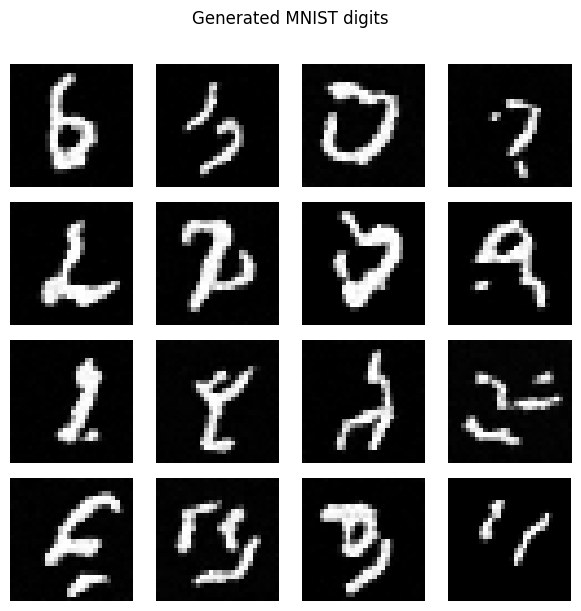

In [24]:
fig, axes = plt.subplots(4,4,figsize=(6,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.suptitle("Generated MNIST digits", y=1.01)
plt.tight_layout()
plt.show()
